# Exploratory Analysis with PCA

This notebook explores the cleaned breast transcriptomics dataset using principal component analysis (PCA). The objective is to reduce the high-dimensional gene expression matrix to a small number of components that can be visualized and interpreted.

The analysis is organized into five steps:

1. load the cleaned feature matrix and labels,
2. standardize gene expression values,
3. compute the principal components,
4. visualize the samples in PCA space by binary label,
5. compare the same projection with the original sample subtypes.

In [1]:
# Imports
from pathlib import Path
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [2]:
# Path
project_root = Path.cwd()
if not (project_root / "data").exists():
    project_root = project_root.parent

# Get data path
data_path = str(project_root) + "/data"

## Step 1: Load the processed dataset

We reuse the cleaned outputs produced in Notebook 01:

- `X_clean.csv` contains the gene expression matrix,
- `y_clean.csv` contains the binary target labels.

The call to `.squeeze()` converts the one-column label table into a pandas `Series`, which is the expected 1D format for the target vector.

In [3]:
X = pd.read_csv(data_path + "/processed/X_clean.csv")
y = pd.read_csv(data_path + "/processed/y_clean.csv").squeeze()

## Step 2: Standardize the gene expression matrix

PCA is sensitive to the relative scale of the input variables. Because some genes can show larger variance than others, we standardize each feature before running PCA so that the projection reflects coordinated structure across genes rather than raw magnitude differences.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Step 3: Run PCA and inspect explained variance

We fit PCA with two components in order to create a two-dimensional representation of the samples. The explained variance ratio shows how much of the total variability is captured by `PC1` and `PC2`, which helps assess how informative the 2D projection is.

In [5]:
# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Variance ratio
pca.explained_variance_ratio_


array([0.12914123, 0.07227092])

// TODO explain resulting variance

## Step 4: Visualize the PCA projection by binary label

The first scatter plot displays the samples using the two principal components, colored by the cleaned labels (`normal` and `tumor`). This gives a first view of whether the two classes tend to separate in a lower-dimensional space.

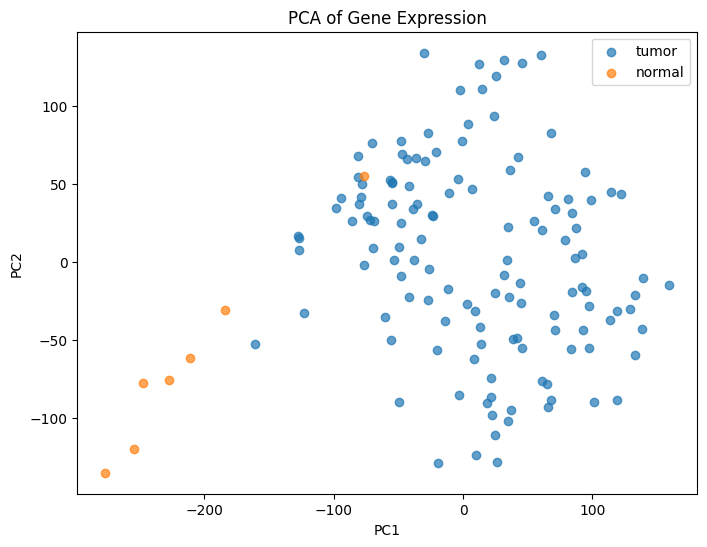

In [11]:
plt.figure(figsize=(8,6))

for label in y.unique():
    idx = (y == label)
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=label, alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Gene Expression")
plt.legend()
plt.show()

## Interpreting the PCA output

PCA is an unsupervised method, so it does not use the class labels when constructing the projection. Any visible grouping therefore reflects structure already present in the expression matrix.

If the two classes occupy different regions of the plot, this suggests that the transcriptomic profiles carry meaningful signal for downstream classification. If the classes overlap strongly, it indicates that class separation may require more dimensions or more flexible models than a simple linear projection.

We observe that the normal samples are clearly grouped on the left side in a small cluser being mostly separated by PC1, indicaating a consistent gene expression profile. The tumor samples are more heteregeneously spread accross the space, partially overlapping but mostly distinct: this is the result of different cancer subtypes behaving differently indicating a high biological variability. Morover ther is clear separation between normal and tumor cells along PC1. This translates clearly as the main source of variation in the dataaset is the difference between healthy and cancer tissue.

There is a couple of borderline points (normal cell in tumor cluster and overlapping tumorous cells) that can be due to biological variablity or measurment noise but as they represent a minority of the total sample pool we can safely ignore them.

Overall, PCA reveals a clear separation between tumor and normal samples, indicating that global gene expression profiles strongly differ between the two conditions. Normal samples form a tight cluster, while tumor samples display higher heterogeneity.

## Step 5: Revisit the projection with the original sample types

The binary labels are useful for classification, but they also merge several tumor-related categories into a single group. To better understand the structure hidden inside that `tumor` label, we reload the original metadata from the raw dataset, remove `cell_line` samples as before, and color the same PCA coordinates by the original `type` column.

This second view helps answer a different question: whether the global variation in the dataset is driven only by the normal-versus-tumor split, or whether additional subtype-level structure is also present among the tumor samples.

In [7]:
df = pd.read_csv(data_path + "/raw/Breast_GSE45827.csv")

In [8]:
df = df[df['type'] != 'cell_line'].copy()
types = df.loc[df.index, 'type']

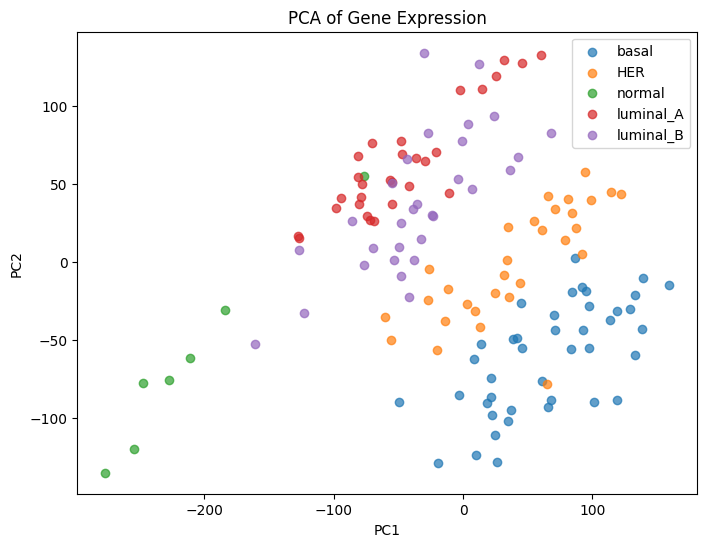

In [9]:
plt.figure(figsize=(8,6))

for t in types.unique():
    idx = (types == t)
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=t, alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Gene Expression")
plt.legend()
plt.show()


# Interpreting the PCA output with multiple cell types

Normal samples are grouped far on the left, mainly separated along PC1. This implies that normal tissue has a transcriptional profile clrealy diffferent from tumor tissue. It confirms that the dataset contains a strong disease related signal. 

Basal samples are concentrated mostly in lower right part: they appear trabscriptionally different from the other cancer types. Biologically speaking, this is plausible since basal-like breast cancers are often molecularly distinct and more aggressive. 

Luminal A et luminal B are related but not identical. They occupy neighboring regions with notable overlap but not completely mixed. This implies that the two subtypes are biologically closer to each other than basal and normal for instance. As they share some molecular features but still differ enough, the partial overlap was excpected.

HER tumors appear more central/right and partially overlap with other groups. This indicates that HER have their own structure but are not as cleanly isolated as basal or normal cells. This can happen because subtype boundaries are not perfectly discrete in real data or it can reflect sample heteregeneity and/or limited sample size.

From the plot, PC1 seems to separate normal tissue vs tumors very strongly and contribute to subtype separation (although lightly). It likely reflects a major axis of transcriptomic change associated with the transition from healthy tissue to cancer. PC2 seems to help separate tumor subtypes from one another: it may reflect variation internal to tumor biology rather than normal vs tumor.

Binary cell type PCA revealed a strong global separation between normal and tumor samples, indicating that breast cancer status is a major driver of transcriptomic variation in the dataset. When coloring samples by subtype, additional internal structure emerged: basal samples formed a relatively distinct cluster, while luminal A and luminal B showed partial overlap consistent with related but non-identical molecular profiles. Overall, the PCA supports both the biological validity of the dataset and the presence of meaningful subtype-specific transcriptional heterogeneity. 